# Graphic 4: Rising Global Temperature (New York Times)
Replication of the New York Times chart "Rising Global Temperature" (Schwartz and Popovich, 2019), which re-plots NASA's GISTEMP v4 global annual mean through 2018, relative to the 1880-1899 average.

## 1. Setup
Import the libraries and define paths relative to the repo root, since this notebook runs from `scripts/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import numpy as np
import pandas as pd


ROOT = Path.cwd().parent
DATA = ROOT /"data"
OUT = ROOT /"outputs"
OUT.mkdir(exist_ok=True)

## 2. Load and clean the data
Same file and cleaning steps as Graphic 3: skip the quoted title and the header, name the columns, and convert them to numbers.

In [2]:
columns = ["year", "annual_mean", "lowess"]
df = pd.read_csv(DATA / "graphic3_global_mean.csv", skiprows= 2, names= columns)
df = df.apply(pd.to_numeric, errors= "coerce")
df = df.dropna(subset= ["year"])
df["year"] = df["year"].astype(int)

df.head()

,year,annual_mean,lowess
0,1880,-0.18,-0.10
1,1881,-0.09,-0.14
2,1882,-0.12,-0.18
3,1883,-0.18,-0.21
4,1884,-0.29,-0.25


## 3. Cut at 2018 and re-baseline
The NYT article was published in February 2019, so keep the years through 2018. NASA measures anomalies against 1951-1980, but the NYT measures them against 1880-1899, so subtract the 1880-1899 mean from every year.

In [3]:
df = df[df["year"] <= 2018].copy()
baseline = df.loc[df["year"].between(1880, 1899), "annual_mean"].mean()
df["anomaly_c"] = df["annual_mean"] - baseline
df["anomaly_f"] = df["anomaly_c"] * 9 / 5  # a difference in °C times 9/5 gives °F

print(f"1880-1899 mean: {baseline:.3f} °C")
print(df.shape)
df.nlargest(4, "anomaly_c")

1880-1899 mean: -0.231 °C
(139, 5)


,year,annual_mean,lowess,anomaly_c,anomaly_f
136,2016,1.01,0.87,1.2405,2.2329
137,2017,0.92,0.91,1.1505,2.0709
135,2015,0.90,0.83,1.1305,2.0349
138,2018,0.85,0.93,1.0805,1.9449


## 4. Create the plot
A function that draws each year as a dot colored by its anomaly, joined by a thin gray line, with the NYT's title, year labels and zero-line notes. It returns the figure and axes.

In [4]:
def plot_nyt(df):
    """Recreate the NYT 'Rising Global Temperature' chart."""
    fig, ax = plt.subplots(figsize=(10, 6))

    # Dot colors: blue below the baseline, white at 0, orange-red above it
    cmap = LinearSegmentedColormap.from_list(
        "nyt", ["#5b8fbf", "#f7f7f7", "#d4694a"])
    norm = TwoSlopeNorm(vmin=-0.3, vcenter=0, vmax=1.3)

    ax.plot(df["year"], df["anomaly_c"], color="#888888", linewidth=0.8, zorder=2)
    ax.scatter(df["year"], df["anomaly_c"], c=df["anomaly_c"], cmap=cmap,
               norm=norm, s=40, edgecolors="#777777", linewidths=0.6, zorder=3)

    # Dotted gridlines and a solid line at the 1880-1899 average
    ax.set_yticks(np.arange(-0.4, 1.21, 0.2))
    ax.yaxis.set_major_formatter(lambda y, pos: f"{y:+.1f}°C".replace("-", "−"))
    ax.grid(axis="y", linestyle=(0, (1, 3)), color="#bbbbbb", linewidth=0.8)
    ax.axhline(0, color="#cccccc", linewidth=1.2, zorder=1)
    ax.set_ylim(-0.45, 1.27)
    ax.set_xticks(range(1880, 2011, 10))
    ax.set_xlim(1878, 2021)
    ax.tick_params(axis="y", length=0, labelsize=10, colors="#666666")
    ax.tick_params(axis="x", labelsize=10, colors="#666666")
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#888888")

    # Title and subtitle inside the plot, as in the NYT version
    ax.text(1900, 1.0, "Rising Global Temperature", fontsize=15,
            fontweight="bold", color="#333333")
    ax.text(1900, 0.97, "How much cooler or warmer every year\nwas compared with "
            "the average\ntemperature of the late 19th century",
            fontsize=11, color="#333333", va="top", linespacing=1.5)

    # Labels for notable years: (x shift, y shift, alignment)
    labels = {1904: (-12, -16, "right"), 1944: (8, 0, "left"),
              1998: (-10, 0, "right"), 2016: (8, 0, "left"), 2018: (8, -4, "left")}
    for year, (dx, dy, ha) in labels.items():
        y = df.loc[df["year"] == year, "anomaly_c"].item()
        ax.annotate(str(year), (year, y), xytext=(dx, dy),
                    textcoords="offset points", ha=ha, va="center", fontsize=11,
                    fontweight="bold" if year == 2018 else "normal")

    # Notes above and below the zero line
    ax.text(2020, 0.04, "HOTTER THAN THE\n1880-1899 AVERAGE", ha="right",
            va="bottom", fontsize=8, color="#333333", linespacing=1.6)
    ax.text(2020, -0.04, "COLDER", ha="right", va="top", fontsize=8, color="#333333")

    fig.text(0.125, 0.0, "Source: NASA | By The New York Times", fontsize=9,
             color="#888888")
    return fig, ax

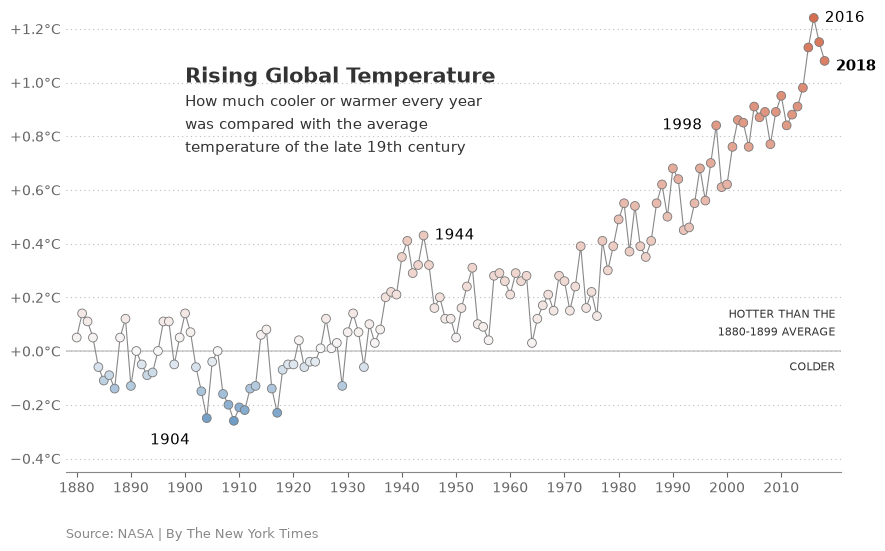

In [5]:
fig, ax = plot_nyt(df)

plt.show()

## 5. Save the figure
Save the figure to `outputs/` as both PNG and PDF.

In [6]:
fig.savefig(OUT / "graphic4_nyt_replication.png", dpi=300, bbox_inches="tight")

fig.savefig(OUT / "graphic4_nyt_replication.pdf", bbox_inches="tight", metadata={"CreationDate": None})

## 6. Notes

Relative to the late 19th century, global temperature rose about 1.1 °C by 2018, and 2018 ranks fourth-warmest after 2016, 2017 and 2015, matching the article's headline. Differences from the NYT chart: values are a few hundredths of a degree higher (2016 is +1.24 °C here vs about +1.22 °C in the NYT) because NASA has revised GISTEMP v4 since 2019; the article headline is left out because it belongs to the article, not the chart; and colors and fonts (the NYT uses its own typeface) are approximated by eye.